<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/SVM_On_Liver_Patient_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Step 2: Load the dataset
data = pd.read_csv('indian_liver_patient.csv')

In [ ]:
# Step 3: Handle missing values
# Check for missing values in the dataset
data.isnull().sum()
data.dropna(inplace=True)

In [ ]:
# step-4:Convert Dataset column: 1 -> 1 (disease), 2 -> 0 (no disease)
data['Dataset'] = data['Dataset'].map({1: 1, 2: 0})
# Convert 'Gender' column to numerical (e.g., Male: 1, Female: 0)
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

In [ ]:
# Step 5: Define features (X) and target (y)
# Features = all columns except 'Dataset'
X = data.drop(columns=['Dataset'])
# Target = 'Dataset' column
y = data['Dataset']

In [ ]:
# Step 6: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Step 7: Train the SVM model
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Step 8: Make predictions on the test set
y_pred = svm_model.predict(X_test)

In [ ]:
# Step 9: Evaluate the model using confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
# Print results
print("Confusion Matrix:")
print(cm)
print("\nAccuracy Score:", accuracy)

Confusion Matrix:
[[  0  61]
 [  0 113]]

Accuracy Score: 0.6494252873563219


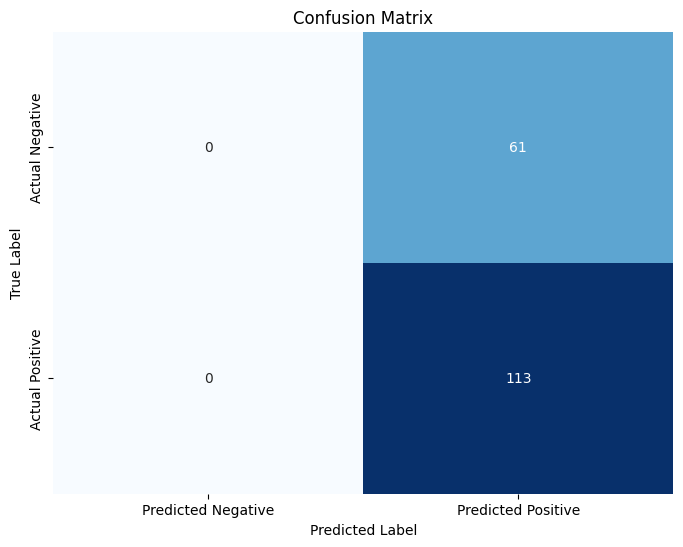

In [ ]:

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()